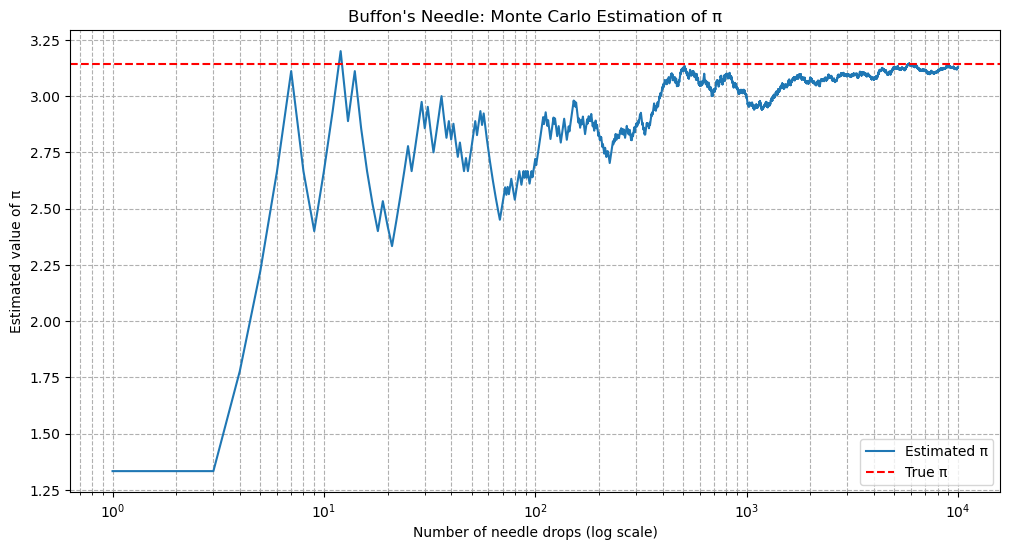

Final estimate after 10000 drops: π ≈ 3.128421711246676
Percentage error: 0.42%


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def buffons_needle_simulation(num_drops, needle_length, line_spacing):
    """
    Simulate Buffon's needle experiment to estimate π
    
    Parameters:
    num_drops (int): Number of needle drops to simulate
    needle_length (float): Length of the needle (l ≤ d)
    line_spacing (float): Distance between parallel lines (d)
    
    Returns:
    tuple: (estimated π values at each step, crossing counts at each step)
    """
    # Generate all random values at once for efficiency
    x = np.random.uniform(0, line_spacing/2, num_drops)
    theta = np.random.uniform(0, np.pi/2, num_drops)
    
    # Determine which drops result in crossings
    crossings = (needle_length/2 * np.sin(theta)) >= x
    cumulative_crossings = np.cumsum(crossings)
    
    # Calculate π estimates at each step
    n = np.arange(1, num_drops + 1)
    pi_estimates = (2 * needle_length * n) / (line_spacing * cumulative_crossings)
    
    return pi_estimates, cumulative_crossings

# Simulation parameters
num_drops = 10000
needle_length = 1.0  # l ≤ d
line_spacing = 1.5   # d

# Run simulation
pi_estimates, crossings = buffons_needle_simulation(num_drops, needle_length, line_spacing)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(np.arange(1, num_drops + 1), pi_estimates, label='Estimated π')
plt.axhline(y=np.pi, color='r', linestyle='--', label='True π')
plt.xscale('log')
plt.xlabel('Number of needle drops (log scale)')
plt.ylabel('Estimated value of π')
plt.title('Buffon\'s Needle: Monte Carlo Estimation of π')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Final estimate
final_pi = pi_estimates[-1]
print(f"Final estimate after {num_drops} drops: π ≈ {final_pi}")
print(f"Percentage error: {abs(final_pi - np.pi)/np.pi * 100:.2f}%")